In [1]:
from utils_ml import *

In [2]:
old_label_arr = np.array([np.tile(i, 3000) for i in np.arange(0,8)]).flatten()

# Define the mapping from class labels (0 to 7) to the new 3-element array format
# where each element in the array represents the number of poles on [bt], [bb], and [tb]
class_to_poles = {
    0: [1, 0, 0],  # 1 pole on [bt]
    1: [0, 1, 0],  # 1 pole on [bb]
    2: [0, 0, 1],  # 1 pole on [tb]
    3: [1, 1, 0],  # 1 pole on [bt] and 1 pole on [bb]
    4: [0, 1, 1],  # 1 pole on [bb] and 1 pole on [tb]
    5: [1, 1, 1],  # 1 pole on each of [bt], [bb], and [tb]
    6: [0, 2, 1],  # 2 poles on [bb] and 1 pole on [tb]
    7: [0, 1, 2]   # 1 pole on [bb] and 2 poles on [tb]
}

new_label_arr = convert_labels(old_label_arr, class_to_poles)

In [3]:
features_regression = np.load('data/features_selected.npy', mmap_mode='r+')
X_train, X_test, y_train, y_test = train_test_split(features_regression, new_label_arr,random_state=42, test_size=0.1)

In [4]:
# Train Pool for CatBoost (multi-output regression requires separate models per target)
models = []
preds = []
data_uncertainty = []
knowledge_uncertainty = []

for i in range(y_train.shape[1]):
    train_pool = Pool(X_train, y_train[:, i])
    
    model = CatBoostRegressor(
    verbose=100,           
      random_state=42,
      loss_function="RMSE",
        )
    model.fit(train_pool, use_best_model=False)
    models.append(model)

    pred = model.predict(X_test)
    preds.append(pred)  
   
# Convert lists to arrays for easier manipulation
preds = np.column_stack(preds)


Learning rate set to 0.066531
0:	learn: 0.4618134	total: 86.7ms	remaining: 1m 26s
100:	learn: 0.1640924	total: 4.59s	remaining: 40.9s
200:	learn: 0.1362070	total: 9.21s	remaining: 36.6s
300:	learn: 0.1200426	total: 13.8s	remaining: 32s
400:	learn: 0.1081800	total: 18s	remaining: 26.9s
500:	learn: 0.0987951	total: 22.2s	remaining: 22.1s
600:	learn: 0.0913315	total: 26.4s	remaining: 17.5s
700:	learn: 0.0846856	total: 30.6s	remaining: 13s
800:	learn: 0.0787671	total: 34.9s	remaining: 8.68s
900:	learn: 0.0735891	total: 39.1s	remaining: 4.3s
999:	learn: 0.0690952	total: 43.3s	remaining: 0us
Learning rate set to 0.066531
0:	learn: 0.5711081	total: 36.2ms	remaining: 36.2s
100:	learn: 0.2168258	total: 4.32s	remaining: 38.5s
200:	learn: 0.1859859	total: 8.56s	remaining: 34s
300:	learn: 0.1668238	total: 12.8s	remaining: 29.8s
400:	learn: 0.1532879	total: 17.1s	remaining: 25.5s
500:	learn: 0.1431327	total: 21.6s	remaining: 21.5s
600:	learn: 0.1346650	total: 25.9s	remaining: 17.2s
700:	learn: 0.12

In [9]:
# Initialize variables for storing results
kfold_models = []  # Models trained per fold
preds = []  # Predictions from each fold
data_uncertainty = []  # Placeholder for uncertainty values (if needed)
knowledge_uncertainty = []  # Placeholder for uncertainty values (if needed)

# Set up 5-fold cross-validation
kfold = KFold(n_splits=2, shuffle=True, random_state=42)

# Loop through each target in y_train
for target_idx in range(y_train.shape[1]):
    target_models = []  # Models for this specific target
    target_preds = []  # Predictions for this target

    # Cross-validation loop
    for fold, (train_idx, val_idx) in enumerate(kfold.split(X_train)):
        # Create data pools for training and validation
        train_pool = Pool(X_train[train_idx], y_train[train_idx, target_idx])
        val_pool = Pool(X_train[val_idx], y_train[val_idx, target_idx])

        # Define the model
        model = CatBoostRegressor(
            verbose=100,
            random_state=42,
            loss_function="RMSE",
        )

        # Train the model
        model.fit(
            train_pool,
            eval_set=val_pool,
            verbose=100,
            plot=False,
            depth=8
        )
        
        # Save the model
        # model.save_model(f"saved_models/model_fold_target_{target_idx}_fold_{fold}.cbm")
        target_models.append(model)

        # Make predictions on the validation set
        val_pred = model.predict(X_train[val_idx])
        target_preds.append(val_pred)

    # Store models and predictions for this target
    kfold_models.append(target_models)
    preds.append(np.concatenate(target_preds, axis=0))

# Convert predictions to a single array (rows correspond to samples, columns to targets)
final_preds = np.column_stack(preds)


Learning rate set to 0.073985
0:	learn: 0.4605192	test: 0.4594961	best: 0.4594961 (0)	total: 39.1ms	remaining: 39s
100:	learn: 0.1588478	test: 0.1753494	best: 0.1753494 (100)	total: 4.32s	remaining: 38.5s
200:	learn: 0.1271242	test: 0.1584149	best: 0.1584149 (200)	total: 8.33s	remaining: 33.1s
300:	learn: 0.1072204	test: 0.1509599	best: 0.1509599 (300)	total: 12.3s	remaining: 28.5s
400:	learn: 0.0933691	test: 0.1464454	best: 0.1464454 (400)	total: 16.2s	remaining: 24.2s
500:	learn: 0.0831999	test: 0.1442666	best: 0.1442654 (499)	total: 20.1s	remaining: 20s
600:	learn: 0.0742582	test: 0.1421123	best: 0.1421123 (600)	total: 24s	remaining: 15.9s
700:	learn: 0.0667386	test: 0.1405678	best: 0.1405553 (699)	total: 27.8s	remaining: 11.8s
800:	learn: 0.0607089	test: 0.1394450	best: 0.1394450 (800)	total: 31.5s	remaining: 7.83s
900:	learn: 0.0547731	test: 0.1382713	best: 0.1382713 (900)	total: 35.4s	remaining: 3.89s
999:	learn: 0.0501171	test: 0.1375618	best: 0.1375557 (998)	total: 39.3s	remain

In [36]:
# Initialize a list to store fold-wise predictions for accuracy calculation
fold_accuracies = []
mean_predictions = []  # Store mean predictions over folds

# Loop through each fold's models to gather predictions and compute accuracy
for fold_idx in range(len(kfold_models[0])):  # Assuming 5 models for 5 folds
    fold_preds = []
    
    # Collect predictions for all targets for the current fold
    for target_idx in range(y_test.shape[1]):
        # Get predictions from the current fold's model for this target
        fold_preds.append(kfold_models[target_idx][fold_idx].predict(X_test))
    
    # Stack predictions for all targets
    fold_preds = np.column_stack(fold_preds)
    
    # Process predictions for accuracy calculation
    rounded_preds = np.round(fold_preds)
    
    # Compute accuracy for this fold
    accuracy = np.sum(np.sum(rounded_preds == y_test, axis=1) == y_test.shape[1]) / y_test.shape[0]
    fold_accuracies.append(accuracy)
    
    # Add the fold's predictions to mean predictions
    if not mean_predictions:
        mean_predictions = [fold_preds]
    else:
        mean_predictions.append(fold_preds)

# Calculate the mean predictions across folds
mean_predictions = np.mean(mean_predictions, axis=0)

# Convert mean predictions using the reconvert_labels function
final_predictions = reconvert_labels(np.abs(np.round(mean_predictions)).tolist(), class_to_poles)

# Compute the mean and standard deviation of accuracies across folds
mean_accuracy = np.mean(fold_accuracies)
std_accuracy = np.std(fold_accuracies)

# Print the results
print(f"Mean Test Accuracy = {mean_accuracy:.4f}")
print(f"Standard Deviation of Test Accuracy = {std_accuracy:.4f}")


Mean Test Accuracy = 0.8844
Standard Deviation of Test Accuracy = 0.0019


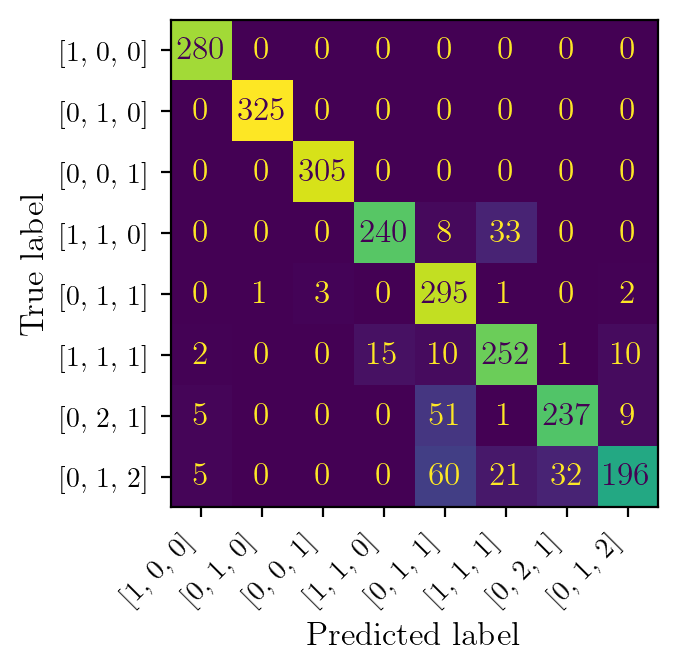

In [ ]:
# Custom class-to-poles mapping
class_to_poles = {
    0: [1, 0, 0],  # 1 pole on [bt]
    1: [0, 1, 0],  # 1 pole on [bb]
    2: [0, 0, 1],  # 1 pole on [tb]
    3: [1, 1, 0],  # 1 pole on [bt] and 1 pole on [bb]
    4: [0, 1, 1],  # 1 pole on [bb] and 1 pole on [tb]
    5: [1, 1, 1],  # 1 pole on each of [bt], [bb], and [tb]
    6: [0, 2, 1],  # 2 poles on [bb] and 1 pole on [tb]
    7: [0, 1, 2]   # 1 pole on [bb] and 2 poles on [tb]
}

# Custom labels for the axes
custom_labels = [str(class_to_poles[i]) for i in range(len(class_to_poles))]

mean_predictions = reconvert_labels(np.round(mean_predictions),class_to_poles)
custom_labels = [str(class_to_poles[i]) for i in range(len(class_to_poles))]

# Compute the confusion matrix
cm = confusion_matrix(reconvert_labels(y_test, class_to_poles), mean_predictions, labels=np.arange(len(class_to_poles)))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(len(class_to_poles)))
fig, ax = plt.subplots(figsize=(3.54331, 3.54331))  # Adjust figure size if needed
disp.plot(ax=ax,colorbar=False)

# Update x and y axis tick labels with the custom labels
ax.set_xticks(np.arange(len(custom_labels)))
ax.set_yticks(np.arange(len(custom_labels)))
ax.set_xticklabels(custom_labels, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(custom_labels, fontsize=10)

# Adjust layout for readability
plt.tight_layout()
plt.show()

In [41]:
# # Number of classes
# num_classes = 8

# # Initialize an array to store accuracies for each class across folds
# class_accuracies_folds = np.zeros((len(kfold_models), num_classes))

# # Calculate per-class accuracy for each fold
# for fold_idx, model in enumerate(kfold_models):
#     fold_accuracies = []
#     for cls in range(num_classes):
#         # Mask for the current class
        
#         class_mask = (reconvert_labels(y_test, class_to_poles) == cls)
#         # Calculate accuracy for the current fold and class
#         # /np.sum(np.ones_like(y_test[:,0]))
#         class_accuracy = np.sum(np.sum(np.round(_pred[class_mask])==y_test[class_mask],axis=1) == 3) / np.sum(class_mask)
#         fold_accuracies.append(class_accuracy)
#     class_accuracies_folds[fold_idx] = fold_accuracies

# # Compute mean and standard deviation of accuracies across folds
# class_accuracies_mean = class_accuracies_folds.mean(axis=0)
# class_accuracies_std = class_accuracies_folds.std(axis=0)

# # Bar plot with error bars
# fig, ax = plt.subplots(figsize=(3.54331, 3.54331*0.75))
# ax.bar(range(num_classes), class_accuracies_mean, yerr=class_accuracies_std,  capsize=5)
# ax.set_ylabel('Accuracy')

# ax.set_xticks(np.arange(len(custom_labels)))
# ax.set_xticklabels(custom_labels, rotation=45, ha='right', fontsize=10)

# ax.set_ylim(0.5, 1.01)  # Accuracy goes from 0 to 1
# plt.tight_layout()
# plt.show()

